In [1]:
# laod data
in_dir <- "data/original_network/"
out_dir <- "data/adj_network/"

Austria_spieceasi <- read.delim(file.path(in_dir, "Austria_spieceasi_net.tsv"), header = TRUE)
Italy1_spieceasi <- read.delim(file.path(in_dir, "Italy1_spieceasi_net.tsv"), header = TRUE)
Italy2_spieceasi <- read.delim(file.path(in_dir, "Italy2_spieceasi_net.tsv"), header = TRUE)

In [3]:
source('utilities.R')

# sparsify network and transform to adjacency matrix
library(dplyr)
library(tidyr)
library(reshape2)

#
list_spieceasi <- list(
  Austria_spieceasi = Austria_spieceasi,
  Italy1_spieceasi = Italy1_spieceasi,
  Italy2_spieceasi = Italy2_spieceasi
)

adj_sp <- process_network_dfs(list_spieceasi, filter_enabled = TRUE, quantiles = 0)



[1] "Austria_spieceasi keeping associations that > 0."
[1] "Italy1_spieceasi keeping associations that > 0."
[1] "Italy2_spieceasi keeping associations that > 0."


Warning message:
"Paket 'purrr' wurde unter R Version 4.4.1 erstellt"


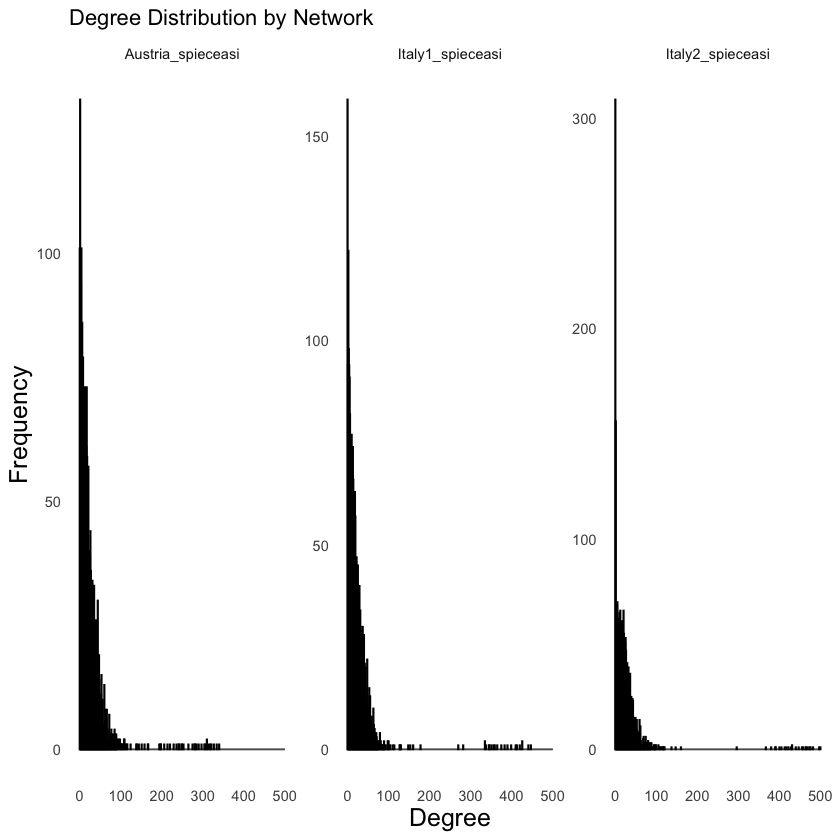

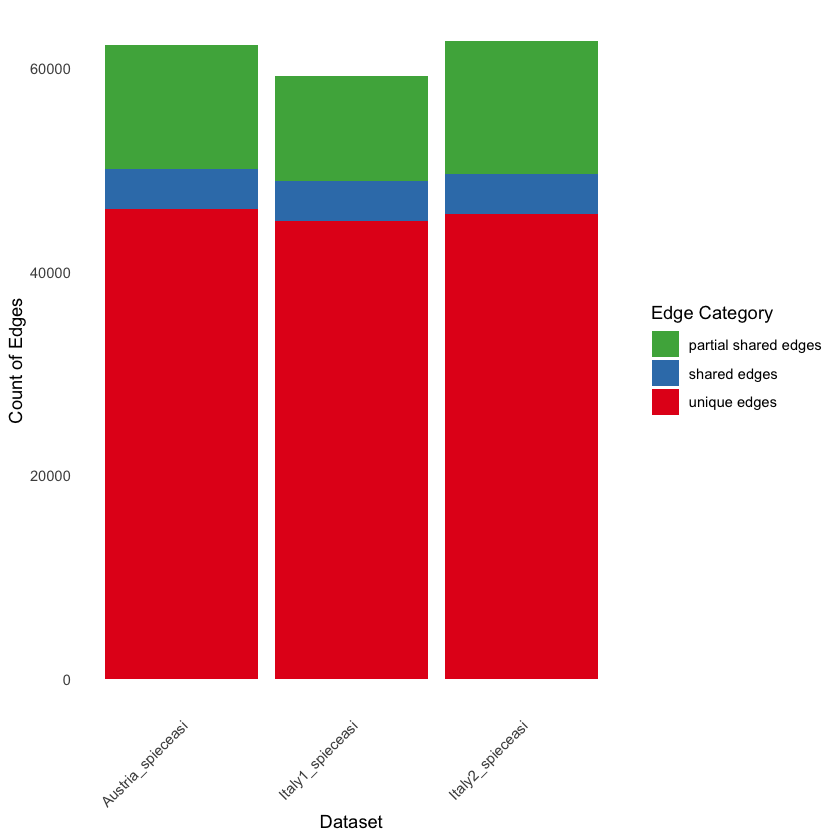

network1,network2,total_edges,edges_A,edges_B,overlap,p_value
<chr>,<chr>,<int>,<int>,<int>,<int>,<dbl>
Austria_spieceasi,Italy1_spieceasi,6953769,62266,59275,8649,0
Austria_spieceasi,Italy2_spieceasi,6953769,62266,62672,11315,0
Italy1_spieceasi,Italy2_spieceasi,6953769,59275,62672,9534,0


Warning message:
"Paket 'igraph' wurde unter R Version 4.4.1 erstellt"

Attache Paket: 'igraph'


Die folgenden Objekte sind maskiert von 'package:purrr':

    compose, simplify


Das folgende Objekt ist maskiert 'package:tidyr':

    crossing


Die folgenden Objekte sind maskiert von 'package:dplyr':

    as_data_frame, groups, union


Die folgenden Objekte sind maskiert von 'package:stats':

    decompose, spectrum


Das folgende Objekt ist maskiert 'package:base':

    union


Warning message:
"Paket 'pheatmap' wurde unter R Version 4.4.1 erstellt"


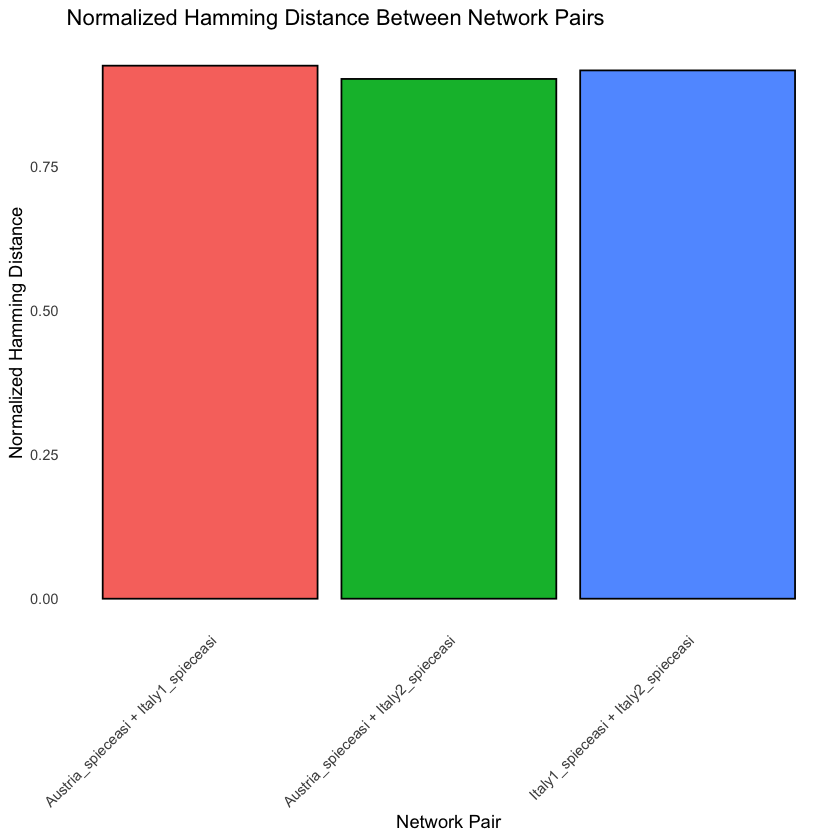

,Austria_spieceasi,Italy1_spieceasi,Italy2_spieceasi
Austria_spieceasi,1.0000000,0.4139224,0.4885534
Italy1_spieceasi,0.4139224,1.0000000,0.4065606
Italy2_spieceasi,0.4885534,0.4065606,1.0000000


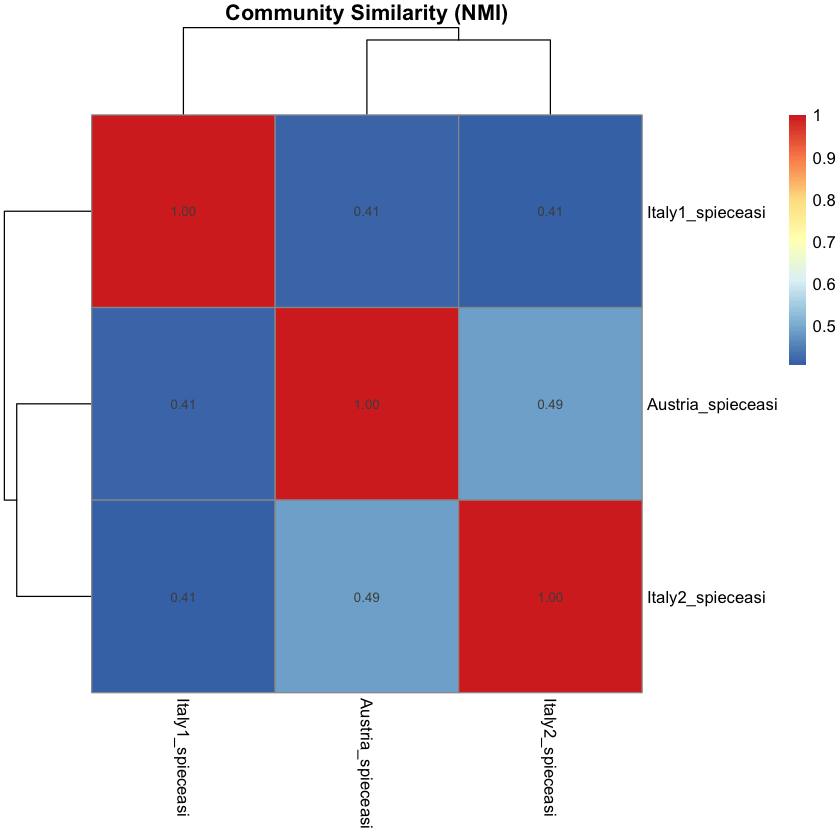

In [4]:
# whole network similarity -- visualization
# compare networks by dataset -- (use adjacency matrix of "spieceasi"), the following functions include:
# plot degree distribution
# plot edge overlap
# plot hanmming distance
# compare hypergeometric overlap
# compare communities

library(ggplot2)
library(purrr)
# spieceasi

plot_degree_distributions(adj_sp, binwidth = 1)
plot_edge_overlap(adj_sp)
plot_normalized_hamming_distance(adj_sp)
compare_hypergeometric_overlap(adj_sp)
compare_communities(adj_sp, method = "nmi", plot = TRUE)

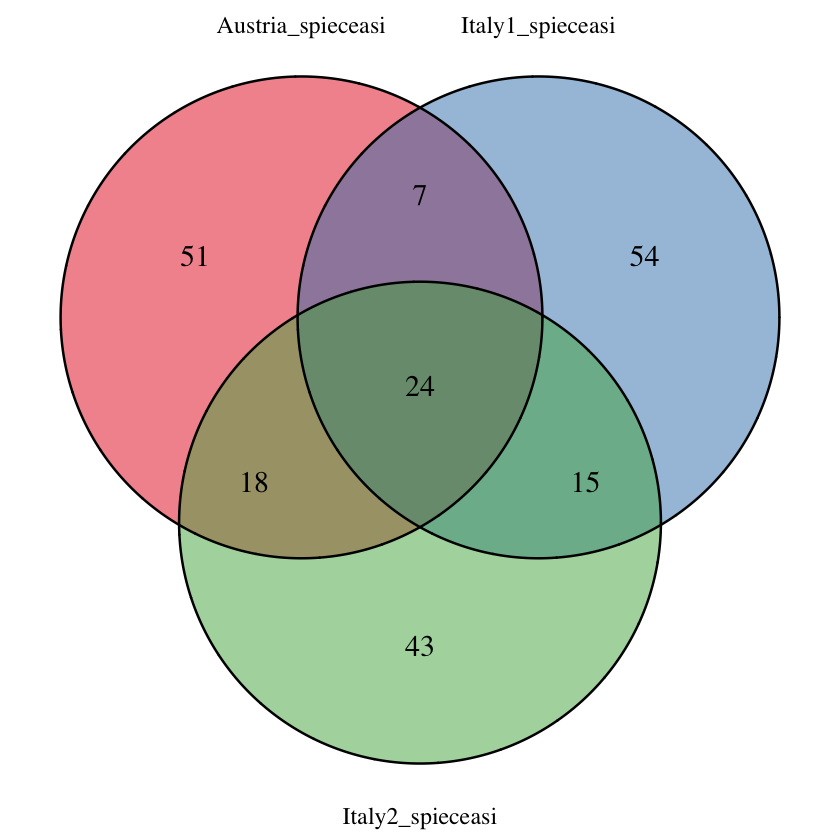

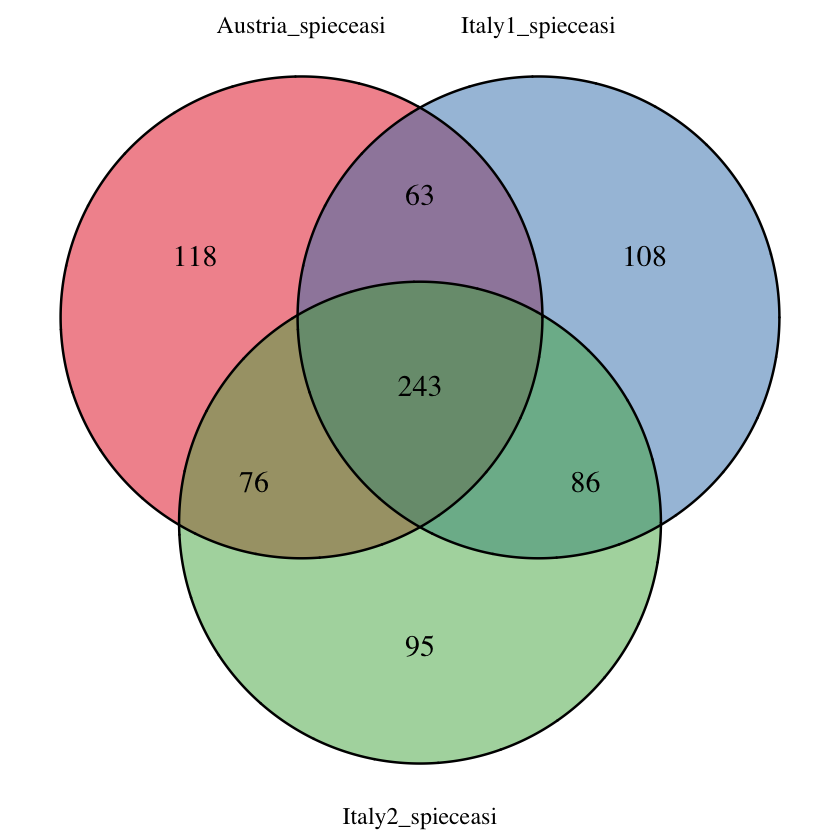

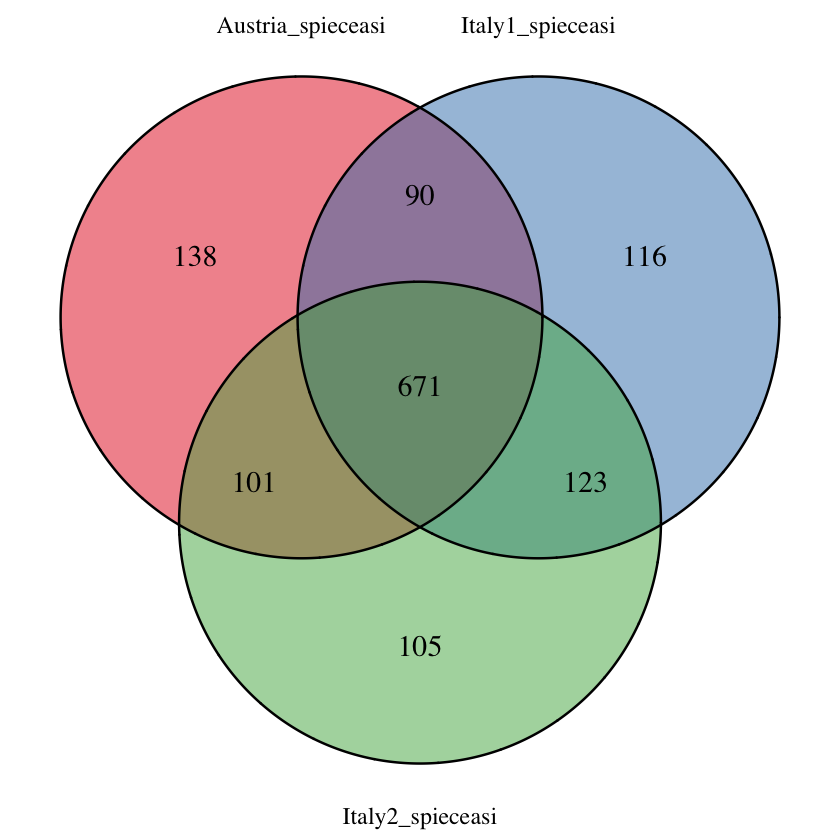

In [ ]:
# compare hub

library(VennDiagram)

plot_hub_venn <- function(adj_list, top_n = 100) {
  # Step 1: calculate degree of adjacency matrix， extract hub nodes
  top_node_sets <- lapply(adj_list, function(mat) {
    degs <- rowSums(mat != 0)
    names(sort(degs, decreasing = TRUE)[1:min(top_n, length(degs))])
  })

  # Step 2: check number of sets (2 to 5), VennDiagram package supports 2 to 5 sets
  n_sets <- length(top_node_sets)
  if (n_sets < 2 || n_sets > 5) {
    stop("VennDiagram package supports between 2 and 5 sets.")
  }

  # Step 3: generate Venn plot
  names(top_node_sets) <- names(adj_list)  # set names for the sets
  venn.plot <- venn.diagram(
    x = top_node_sets,
    category.names = names(top_node_sets),
    filename = NULL,
    output = TRUE,
    imagetype = "png",
    col = "black",
    fill = c("#E41A1C", "#377EB8", "#4DAF4A", "#984EA3", "#FF7F00")[1:n_sets],
    alpha = 0.5,
    cex = 1.5,
    cat.cex = 1.2,
    cat.pos = 0,
    cat.dist = c(0.05, 0.05, -0.45) # adjust label distances
  )

  # Step 4: plot
  grid.newpage()
  grid.draw(venn.plot)
}


plot_hub_venn(adj_sp,top_n = 100)
plot_hub_venn(adj_sp,top_n = 500)
plot_hub_venn(adj_sp,top_n = 1000)